<a href="https://colab.research.google.com/github/Sidahmed8/arabic-text-summarization-mt5/blob/main/arabic_text_summarization_mt5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automatic Text Summarization for Arabic News Articles

In [ ]:
# 1. INSTALLATION DES DÉPENDANCES
# ============================================================================
!pip install -q datasets transformers accelerate sentencepiece rouge-score evaluate scikit-learn sacrebleu rouge-score



  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.1 MB/s eta 0:00:00


In [ ]:
# 2. IMPORTS
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import re
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
    TrainerCallback
)
from sklearn.feature_extraction.text import TfidfVectorizer


# Télécharger les ressources NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# 3. CHARGEMENT DES DONNÉES
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

# Charger votre dataset
df = pd.read_csv('/content/drive/MyDrive/NLP/AbsArSumCorpus_DW_article tab lead.csv', sep='\t', header=None, engine='python', on_bad_lines='skip')  # Modifier le chemin

print(f"✅ Fichier chargé avec succès !")
print(f"📊 Dimensions brutes : {df.shape}")

# Nettoyer les colonnes
# Renommer les colonnes après le chargement pour correspondre à l'original
if df.shape[1] == 3:
    df.columns = ['id', 'article', 'texte']
    df = df.drop(columns=['id'])
elif df.shape[1] == 2:
    df.columns = ['article', 'texte']

df = df[['article', 'texte']].dropna()
print(f"📊 Dimensions après nettoyage : {df.shape}")

print("\n--- Aperçu des données ---")
print(df.head(2))

Mounted at /content/drive
✅ Fichier chargé avec succès !
📊 Dimensions brutes : (49604, 3)
📊 Dimensions après nettoyage : (49604, 2)

--- Aperçu des données ---
                                             article  \
0  حقق حزب "البديل من أجل ألمانيا" اليميني الشعبو...   
1  بدأت اليوم الجمعة( 23 أيلول/ سبتمبر 2016 ) في ...   

                                               texte  
0  تشير آخر استطلاعات الرأي الألمانية إلى تقدم حز...  
1  بدأت محكمة ميونخ النظر في اتهامات متعلقة برجل ...  



📊 Statistiques de longueur (mots):
        article_len   summary_len
count  49604.000000  49604.000000
mean     376.541327     33.537316
std      223.121282      3.732848
min       33.000000      2.000000
25%      221.000000     32.000000
50%      314.000000     34.000000
75%      476.000000     36.000000
max     2898.000000     45.000000


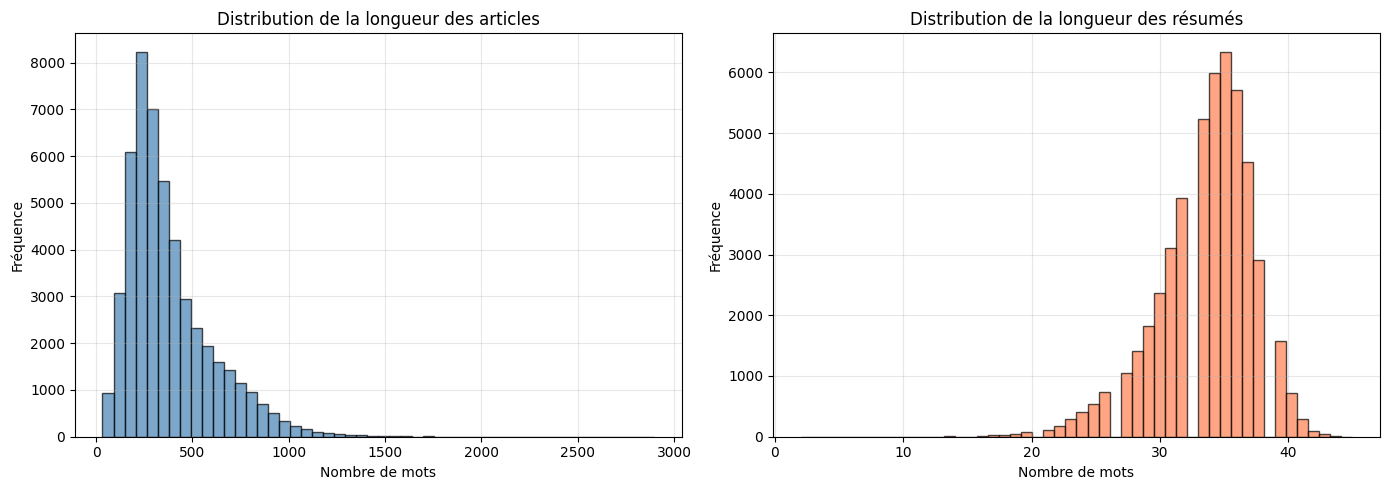


📈 Ratio moyen (résumé/article): 8.91%


In [ ]:
# 4. STATISTIQUES DESCRIPTIVES
# ============================================================================
df['article_len'] = df['article'].apply(lambda x: len(str(x).split()))
df['summary_len'] = df['texte'].apply(lambda x: len(str(x).split()))

print("\n📊 Statistiques de longueur (mots):")
print(df[['article_len', 'summary_len']].describe())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['article_len'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la longueur des articles')
axes[0].grid(alpha=0.3)

axes[1].hist(df['summary_len'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution de la longueur des résumés')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Ratio moyen (résumé/article): {(df['summary_len'].mean() / df['article_len'].mean()):.2%}")

In [ ]:
# 5. PRÉTRAITEMENT NLP
# ============================================================================
arabic_stopwords = set(stopwords.words('arabic'))

def preprocess_arabic_text(text):
    """Prétraitement complet du texte arabe"""
    if not isinstance(text, str):
        return ""

    # Suppression HTML
    text = re.sub(r'<.*?>', '', text)

    # Normalisation arabe
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)

    # Suppression ponctuation et chiffres
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # Suppression stopwords
    words = text.split()
    words = [w for w in words if w not in arabic_stopwords and len(w) > 2]

    return " ".join(words)

# Appliquer le prétraitement
print("\n🔄 Prétraitement en cours...")
df['clean_article'] = df['article'].apply(preprocess_arabic_text)
df['clean_summary'] = df['texte'].apply(preprocess_arabic_text)

print("✅ Prétraitement terminé!")



🔄 Prétraitement en cours...
✅ Prétraitement terminé!



📌 ANALYSE TF-IDF (mots les plus importants)

🔝 Top 30 mots (TF-IDF moyen) :
        المانيا  ->  0.022571
      الالمانيه  ->  0.021482
            انه  ->  0.021210
          اليوم  ->  0.019872
           وقال  ->  0.018766
       الالماني  ->  0.017448
        المتحده  ->  0.017390
           خلال  ->  0.016414
            عام  ->  0.015892
         الرءيس  ->  0.015613
          سوريا  ->  0.014961
            وفي  ->  0.014621
           ايضا  ->  0.014072
       الاوروبي  ->  0.013422
          العام  ->  0.013240
        الحكومه  ->  0.013219
           اكثر  ->  0.013035
        الاتحاد  ->  0.013013
           رءيس  ->  0.012906
         الماضي  ->  0.012816
         الشرطه  ->  0.012447
           بشكل  ->  0.012311
            حتي  ->  0.012127
           كانت  ->  0.011956
         العالم  ->  0.011658
           يمكن  ->  0.011419
          مدينه  ->  0.011316
       الخارجيه  ->  0.011246
           انها  ->  0.011231
           عاما  ->  0.011229


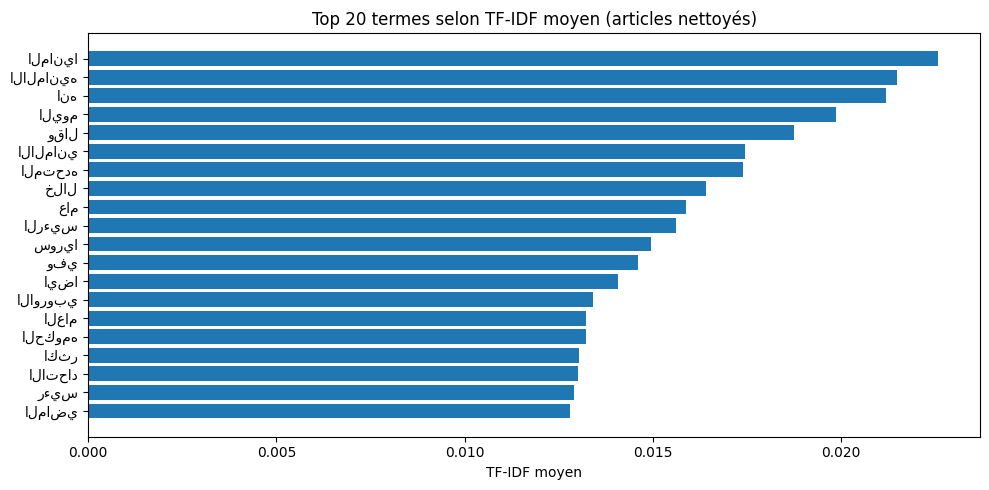


🧾 Exemple mots-clés TF-IDF pour l'article 0 :
[('شعبيه', 0.3693904456787543), ('الاستطلاع', 0.33246862501002533), ('استطلاعات', 0.24684475501038244), ('ارتفعت', 0.23711514606574344), ('الحزب', 0.21407951851938267), ('حزب', 0.19594524900018037), ('بنسبه', 0.18793465741560417), ('الراي', 0.17952804228173347), ('نسبه', 0.16706541294860155), ('الديمقراطي', 0.16526811056995758)]


In [ ]:
# ============================================================================
# 5bis. ANALYSE TF-IDF (Exploration + Mots clés)
# ============================================================================
print("\n" + "="*70)
print("📌 ANALYSE TF-IDF (mots les plus importants)")
print("="*70)

# On travaille sur les textes déjà nettoyés
tfidf_texts = df['clean_article'].astype(str).tolist()

# Vectorizer TF-IDF
# - analyzer='word' : au niveau des mots
# - token_pattern inclut les lettres arabes
# - max_df/min_df pour réduire le bruit
vectorizer = TfidfVectorizer(
    analyzer="word",
    token_pattern=r"(?u)\b[\u0600-\u06FF]{2,}\b",  # mots arabes >= 2 lettres
    max_df=0.90,
    min_df=5,
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(tfidf_texts)
feature_names = np.array(vectorizer.get_feature_names_out())

# Moyenne TF-IDF globale par terme
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_idx = mean_tfidf.argsort()[::-1][:30]

print("\n🔝 Top 30 mots (TF-IDF moyen) :")
for w, s in zip(feature_names[top_idx], mean_tfidf[top_idx]):
    print(f"{w:>15}  ->  {s:.6f}")

# Visualisation (Top 20)
top_k = 20
idx20 = top_idx[:top_k]
plt.figure(figsize=(10, 5))
plt.barh(feature_names[idx20][::-1], mean_tfidf[idx20][::-1])
plt.title("Top 20 termes selon TF-IDF moyen (articles nettoyés)")
plt.xlabel("TF-IDF moyen")
plt.tight_layout()
plt.show()

# --- (Optionnel) : mots-clés TF-IDF d’un article donné ---
def top_tfidf_keywords_for_article(article_text, topn=10):
    clean = preprocess_arabic_text(article_text)
    vec = vectorizer.transform([clean])
    scores = vec.toarray().ravel()
    best = scores.argsort()[::-1][:topn]
    return [(feature_names[i], float(scores[i])) for i in best if scores[i] > 0]

print("\n🧾 Exemple mots-clés TF-IDF pour l'article 0 :")
example_keywords = top_tfidf_keywords_for_article(df.iloc[0]["article"], topn=10)
print(example_keywords)


In [ ]:
# ============================================================================
# 5ter. BASELINE EXTRACTIVE TF-IDF (phrase scoring) -
# ============================================================================
print("\n" + "="*70)
print("🧪 BASELINE EXTRACTIVE (TF-IDF) - Optionnel")
print("="*70)

def split_sentences_ar(text):
    # découpage simple (tu peux améliorer)
    text = str(text)
    sents = re.split(r"[.!؟\n]+", text)
    sents = [s.strip() for s in sents if len(s.strip()) > 0]
    return sents

def tfidf_extractive_summary(article_text, max_sentences=3):
    sents = split_sentences_ar(article_text)
    if len(sents) == 0:
        return ""

    clean_sents = [preprocess_arabic_text(s) for s in sents]
    sent_vec = vectorizer.transform(clean_sents)
    sent_scores = np.asarray(sent_vec.mean(axis=1)).ravel()  # score = moyenne TF-IDF

    best_idx = sent_scores.argsort()[::-1][:max_sentences]
    best_idx = sorted(best_idx)  # garder ordre original
    return " ".join([sents[i] for i in best_idx])

# Test rapide baseline
sample_art = df_train.iloc[0]["article"] if "df_train" in globals() else df.iloc[0]["article"]
print("\n📰 Article (début):", sample_art[:250], "...")
print("\n📌 Résumé TF-IDF baseline:", tfidf_extractive_summary(sample_art, max_sentences=3))



🧪 BASELINE EXTRACTIVE (TF-IDF) - Optionnel

📰 Article (début): حقق حزب "البديل من أجل ألمانيا" اليميني الشعبوي أفضل نتائجه في أحدث استطلاعات الرأي بحصوله على تأييد 16% من الألمان في جميع أنحاء ألمانيا. وأظهر الاستطلاع الذي أجراه معهد "إنفراتست ديماب" بتكليف من شبكة (ARD)إيه آر دي الإعلامية الألمانية أن شعبية الح ...

📌 Résumé TF-IDF baseline: حقق حزب "البديل من أجل ألمانيا" اليميني الشعبوي أفضل نتائجه في أحدث استطلاعات الرأي بحصوله على تأييد 16% من الألمان في جميع أنحاء ألمانيا وأظهر الاستطلاع الذي أجراه معهد "إنفراتست ديماب" بتكليف من شبكة (ARD)إيه آر دي الإعلامية الألمانية أن شعبية الحزب ارتفعت بذلك بنسبة 2% مقارنة باستطلاع مماثل أجري مطلع الشهر الجاري لشبكة(ZDF) تسي دي إف الإخبارية وعن نتائج استطلاعات الرأي، قال وزير شؤون ديوان المستشارية بيتر ألتماير في تصريحات لـ"إيه آر دي" إن استطلاعات الرأي لم تعد تبعث على التفاؤل بالنسبة لأي حزب من الأحزاب الممثلة في البرلمان الألماني (بوندستاغ)


In [ ]:
# 6. NETTOYAGE ET FILTRAGE DES DONNÉES
# ============================================================================
print("\n🧹 Nettoyage des données...")

# Vérifier les données problématiques
print(f"Articles vides (< 20 chars): {(df['clean_article'].str.len() < 20).sum()}")
print(f"Résumés vides (< 10 chars): {(df['clean_summary'].str.len() < 10).sum()}")

# Filtrer les données de qualité
df_clean = df[
    (df['clean_article'].str.len() > 20) &
    (df['clean_summary'].str.len() > 10)
].reset_index(drop=True)

print(f"✅ Dataset nettoyé: {len(df_clean)} exemples (sur {len(df)} initialement)")

# Échantillonnage pour l'entraînement
SAMPLE_SIZE = 8000  # Ajuster selon vos besoins
df_train = df_clean.sample(n=min(SAMPLE_SIZE, len(df_clean)), random_state=42).reset_index(drop=True)

print(f"📦 Dataset d'entraînement: {len(df_train)} exemples")


🧹 Nettoyage des données...
Articles vides (< 20 chars): 0
Résumés vides (< 10 chars): 0
✅ Dataset nettoyé: 49604 exemples (sur 49604 initialement)
📦 Dataset d'entraînement: 8000 exemples


In [ ]:
# 7. CRÉATION DU DATASET HUGGING FACE
# ============================================================================
df_final = df_train[["clean_article", "clean_summary"]].copy()
dataset = Dataset.from_pandas(df_final)

print(f"\n✅ Dataset créé avec {len(dataset)} exemples")
print("\n📄 Exemple:")
print(dataset[0])



✅ Dataset créé avec 8000 exemples

📄 Exemple:
{'clean_article': 'تدور احداث الفيلم قريه نهايه القرن التاسع تسير سياره مرسيدس حديثه الطراز شوارع القريه بينما ينظر قاطنوها الي السياره بعين الريبه الاطفال يلعبون يعترضون فجاه طريق المرسيدس فتنطلق الكوابح اوتوماتيكيا وينجو الاطفال جميعا الا واحدا دهسته السياره تهرع الام خارج منزلها باكيه ادولف ادولف تنتقل الكاميرا الي علامه الطريق لتبين اسم المنطقه براوناو ولد ادولف هتلر شاشه سوداء تتبع المشهد ليظهر الشعار الاعلاني الجديد للكابح الداعم مرسيدس بنز نرصد الخطر وقوعه مرسيدس ورفضها للاعلان انتج الفيلم القصير كمشروع تخرج لعدد طلاب الاكاديميه الالمانيه للافلام بادن فوتمبرغ وشوهد ثلاثه ملايين مره علي يوتيوب حوالي شهر يوجد الفيلم علي الانترنت ويثير عددا النقاشات الناريه ومنذ البدايه اوضحت مرسيدس براءتها الفيلم ويقول الناطق باسمها توبياس مولر نري اللاءق اعتبار وفاه انسان طفل مضامين صله بالنازيه مواد مناسبه للاعلانات حتي وان كانت احداث الفيلم محض خيال فان الماده الاعلانيه وفقا مناسبه ظلال قرار مرسيدس باديا ايضا علي الانترنت سحب الفيلم الانترنت وتضمنت

In [ ]:
# 8. TOKENIZATION AVEC PRÉFIXE MT5
# ============================================================================
MODEL_NAME = "google/mt5-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_INPUT = 512
MAX_TARGET = 128

def preprocess(batch):
    """Prétraitement avec préfixe pour MT5"""
    # IMPORTANT: MT5 nécessite un préfixe de tâche
    inputs = ["summarize: " + text for text in batch["clean_article"]]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT,
        truncation=True,
        padding="max_length"
    )

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            batch["clean_summary"],
            max_length=MAX_TARGET,
            truncation=True,
            padding="max_length"
        )

    # Remplacer les tokens de padding par -100 (ignorés dans la loss)
    labels_ids = labels["input_ids"]
    labels_ids = [
        [(t if t != tokenizer.pad_token_id else -100) for t in label]
        for label in labels_ids
    ]

    model_inputs["labels"] = labels_ids
    return model_inputs

print("\n🔄 Tokenization en cours...")
tokenized_dataset = dataset.map(
    preprocess,
    batched=True,
    remove_columns=dataset.column_names
)

print("✅ Tokenization terminée!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



🔄 Tokenization en cours...


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


✅ Tokenization terminée!


In [ ]:
# 9. VÉRIFICATION DU DATASET TOKENISÉ
# ============================================================================
sample = tokenized_dataset[0]
print("\n🔍 Vérification du dataset tokenisé:")
print(f"Clés: {sample.keys()}")
print(f"Longueur input_ids: {len(sample['input_ids'])}")
print(f"Longueur labels: {len(sample['labels'])}")
print(f"Nombre de -100 dans labels: {sample['labels'].count(-100)}")
print(f"Exemple de labels (20 premiers): {sample['labels'][:20]}")



🔍 Vérification du dataset tokenisé:
Clés: dict_keys(['input_ids', 'attention_mask', 'labels'])
Longueur input_ids: 512
Longueur labels: 128
Nombre de -100 dans labels: 63
Exemple de labels (20 premiers): [6876, 106313, 17824, 4246, 477, 259, 31679, 766, 33012, 39783, 16723, 614, 2820, 259, 212217, 402, 14025, 45319, 46003, 119743]


In [ ]:
# 10. CALLBACK POUR MONITORING
# ============================================================================
class DetailedLoggingCallback(TrainerCallback):
    """Callback pour afficher des logs détaillés"""
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            print(f"\n📊 Step {state.global_step}:")
            for key, value in logs.items():
                print(f"  - {key}: {value}")

In [ ]:
# 11. CHARGEMENT DU MODÈLE ET CONFIGURATION
# ============================================================================
print("\n🤖 Chargement du modèle MT5...")
# Load the model with device_map='auto' to handle large models on limited GPU memory
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, device_map='auto')

# The device is now handled by device_map='auto', so explicit .to(device) is not needed.
# We can still get the main device if needed, but it won't be a single device for the whole model
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model.to(device)
print(f"✅ Modèle chargé avec répartition automatique des périphériques.")



🤖 Chargement du modèle MT5...


pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Modèle chargé avec répartition automatique des périphériques.


In [ ]:
# 12. ARGUMENTS D'ENTRAÎNEMENT
# ============================================================================
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

training_args = TrainingArguments(
    output_dir="./mt5_arasum_finetuned",

    # Batch size
    per_device_train_batch_size=1,      # Réduit de 2 à 1
    gradient_accumulation_steps=16,       # Augmenté de 8 à 16

    # Learning rate
    learning_rate=3e-5,                  # Réduit de 2e-5 à 3e-5
    warmup_steps=200,                    # Ajouté pour stabilité

    # Epochs
    num_train_epochs=3,                  # Augmenté de 2 à 3

    # Précision
    fp16=False,                          # DÉSACTIVÉ (cause des NaN)

    # Gradient checkpointing to save memory
    gradient_checkpointing=True,

    # Gradient clipping (CRUCIAL)
    max_grad_norm=1.0,                   # Limite les gradients

    # Regularization
    weight_decay=0.01,                   # Ajouté

    # Logging et sauvegarde
    logging_steps=50,                    # Log plus fréquent
    save_strategy="epoch",
    save_total_limit=2,                  # Garde seulement les 2 meilleurs

    # Autres
    report_to="none",
    push_to_hub=False,
    load_best_model_at_end=False
)

In [ ]:
# 13. DATA COLLATOR
# ============================================================================
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)


In [ ]:
# 14. TRAINER
# ============================================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[DetailedLoggingCallback()]
)


/tmp/ipython-input-1897579902.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The model is already on multiple devices. Skipping the move to device specified in `args`.


In [ ]:
# 15. ENTRAÎNEMENT
# ============================================================================
print("\n" + "="*70)
print("🚀 DÉBUT DE L'ENTRAÎNEMENT")
print("="*70)

trainer.train()

print("\n" + "="*70)
print("✅ ENTRAÎNEMENT TERMINÉ!")
print("="*70)

# Afficher les statistiques finales
print(f"\n📊 Statistiques finales:")
print(f"  - Nombre d'étapes: {trainer.state.global_step}")
print(f"  - Meilleure loss: {trainer.state.best_metric}")
print(f"\n📜 Historique complet:")
for log in trainer.state.log_history:
    print(f"  {log}")


🚀 DÉBUT DE L'ENTRAÎNEMENT


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
50,13.311000
100,11.388800
150,9.478500
200,6.975500
250,4.531000
300,3.824200
350,3.598300
400,3.547400
450,3.402200
500,3.390900



📊 Step 50:
  - loss: 13.311
  - grad_norm: 3325.03662109375
  - learning_rate: 7.35e-06
  - epoch: 0.1

📊 Step 100:
  - loss: 11.3888
  - grad_norm: 1653.6424560546875
  - learning_rate: 1.485e-05
  - epoch: 0.2

📊 Step 150:
  - loss: 9.4785
  - grad_norm: 1376.807373046875
  - learning_rate: 2.235e-05
  - epoch: 0.3

📊 Step 200:
  - loss: 6.9755
  - grad_norm: 198.9515838623047
  - learning_rate: 2.985e-05
  - epoch: 0.4

📊 Step 250:
  - loss: 4.531
  - grad_norm: 3.5443320274353027
  - learning_rate: 2.886923076923077e-05
  - epoch: 0.5

📊 Step 300:
  - loss: 3.8242
  - grad_norm: 2.771183967590332
  - learning_rate: 2.7715384615384617e-05
  - epoch: 0.6

📊 Step 350:
  - loss: 3.5983
  - grad_norm: 2.6364381313323975
  - learning_rate: 2.6561538461538465e-05
  - epoch: 0.7

📊 Step 400:
  - loss: 3.5474
  - grad_norm: 2.609149694442749
  - learning_rate: 2.5407692307692306e-05
  - epoch: 0.8

📊 Step 450:
  - loss: 3.4022
  - grad_norm: 2.522057294845581
  - learning_rate: 2.425384615

In [ ]:
# 16. SAUVEGARDE DU MODÈLE
# ============================================================================
SAVE_DIR = "/content/mt5_arasum_model"
print(f"\n💾 Sauvegarde du modèle dans {SAVE_DIR}...")

trainer.model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("✅ Modèle sauvegardé!")
!ls -la {SAVE_DIR}


💾 Sauvegarde du modèle dans /content/mt5_arasum_model...
✅ Modèle sauvegardé!
total 2295264
drwxr-xr-x 2 root root       4096 Jan 21 17:32 .
drwxr-xr-x 1 root root       4096 Jan 21 17:31 ..
-rw-r--r-- 1 root root        783 Jan 21 17:31 config.json
-rw-r--r-- 1 root root        152 Jan 21 17:31 generation_config.json
-rw-r--r-- 1 root root 2329638768 Jan 21 17:32 model.safetensors
-rw-r--r-- 1 root root        416 Jan 21 17:32 special_tokens_map.json
-rw-r--r-- 1 root root    4309802 Jan 21 17:32 spiece.model
-rw-r--r-- 1 root root      19282 Jan 21 17:32 tokenizer_config.json
-rw-r--r-- 1 root root   16350195 Jan 21 17:32 tokenizer.json


In [ ]:
# 17. FONCTION DE GÉNÉRATION DE RÉSUMÉS
# ============================================================================
def generate_summary(text, max_new_tokens=128, num_beams=4):
    """Génère un résumé pour un texte donné"""
    # Prétraiter le texte
    clean_text = preprocess_arabic_text(text)

    # Ajouter le préfixe MT5
    input_text = "summarize: " + clean_text

    # Tokenizer
    inputs = tokenizer(
        input_text,
        max_length=512,
        truncation=True,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    # Générer
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
            no_repeat_ngram_size=3,
            length_penalty=1.0
        )

    # Décoder
    summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return summary

In [ ]:
# 18. TEST DE GÉNÉRATION
# ============================================================================
print("\n" + "="*70)
print("🧪 TEST DE GÉNÉRATION")
print("="*70)

# Prendre un exemple du dataset
test_idx = 0
test_article = df_train.iloc[test_idx]['article']
test_reference = df_train.iloc[test_idx]['texte']

print(f"\n📰 Article original (300 premiers chars):")
print(test_article[:300] + "...")

print(f"\n✅ Résumé de référence:")
print(test_reference)

print(f"\n🤖 Résumé généré:")
generated = generate_summary(test_article)
print(generated)


🧪 TEST DE GÉNÉRATION

📰 Article original (300 premiers chars):
تدور أحداث الفيلم في قرية نهاية القرن التاسع عشر، حيث تسير سيارة مرسيدس حديثة الطراز في شوارع القرية، بينما ينظر قاطنوها إلى السيارة بعين الريبة. الأطفال الذين يلعبون يعترضون فجأة طريق المرسيدس، فتنطلق الكوابح أوتوماتيكياً وينجو الأطفال جميعاً إلا واحداً دهسته السيارة. بعد ذلك تهرع الأم خارج منزلها ...

✅ Résumé de référence:
نادراً ما يحظى مشروع تخرج طلابي بهذا الكم من الأضواء. فالفيلم قصير ذو المادة الدعائية مميزة، الذي يدور حول دكتاتور ألماني وسيارة ألمانية وطفل ميت، أثار الكثير من النقاشات حول الهتلريات وغيرها.

🤖 Résumé généré:


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Caching is incompatible with gradient checkpointing in MT5Block. Setting `past_key_values=None`.


قدمت


In [ ]:
model = trainer.model
model.eval()


MT5ForConditionalGeneration(
  (shared): Embedding(250112, 768)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 768)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
         

In [ ]:
# éviter le warning requires_grad
try:
    model.gradient_checkpointing_disable()
except:
    pass

model.config.use_cache = True


In [ ]:
from datasets import Dataset

# df_train existe déjà chez toi (ton échantillon final)
df_eval = df_train[["clean_article", "clean_summary"]].sample(n=min(800, len(df_train)), random_state=42).reset_index(drop=True)

eval_dataset = Dataset.from_pandas(df_eval)

# tokenization avec TA fonction preprocess déjà définie
eval_tokenized = eval_dataset.map(preprocess, batched=True, remove_columns=eval_dataset.column_names)

print("✅ Eval set:", len(eval_tokenized))


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


✅ Eval set: 800


In [ ]:
!pip install -q rouge-score
import re, numpy as np
from rouge_score import rouge_scorer

class ArabicWhitespaceTokenizer:
    def tokenize(self, text):
        text = re.sub(r"[^\w\u0600-\u06FF\s]", " ", str(text))
        text = re.sub(r"\s+", " ", text).strip()
        return text.split() if text else []

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=False,
    tokenizer=ArabicWhitespaceTokenizer()
)

def compute_rouge_ar(preds, refs):
    r1, r2, rl = [], [], []
    for p, r in zip(preds, refs):
        s = scorer.score(r, p)  # (reference, prediction)
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)
    return {
        "rouge1_f": float(np.mean(r1)),
        "rouge2_f": float(np.mean(r2)),
        "rougeL_f": float(np.mean(rl)),
    }


In [ ]:
def evaluate_model_ar(tokenized_ds, n_samples=200, max_new_tokens=128, num_beams=4):
    n = min(n_samples, len(tokenized_ds))
    device = model.get_input_embeddings().weight.device

    preds_text, refs_text = [], []

    for i in range(n):
        x = tokenized_ds[i]

        input_ids = torch.tensor([x["input_ids"]], device=device)
        attention_mask = torch.tensor([x["attention_mask"]], device=device)

        with torch.no_grad():
            out = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                no_repeat_ngram_size=3,
                repetition_penalty=1.2,
                early_stopping=True
            )

        pred = tokenizer.decode(out[0], skip_special_tokens=True)

        labels = [t if t != -100 else tokenizer.pad_token_id for t in x["labels"]]
        ref = tokenizer.decode(labels, skip_special_tokens=True)

        pred = " ".join(pred.split()).strip()
        ref  = " ".join(ref.split()).strip()

        preds_text.append(pred)
        refs_text.append(ref)

    scores = compute_rouge_ar(preds_text, refs_text)
    return scores, preds_text, refs_text

scores, preds_text, refs_text = evaluate_model_ar(eval_tokenized, n_samples=200)
print("✅ ROUGE (Arabic tokenizer):", scores)


✅ ROUGE (Arabic tokenizer): {'rouge1_f': 0.23283766016697416, 'rouge2_f': 0.10430125487744035, 'rougeL_f': 0.19650918277477936}


In [ ]:
for i in range(3):
    print("="*80)
    print("REF:", refs_text[i][:400])
    print("PRED:", preds_text[i][:400])


REF: حصل حزب مواطنون اجل التنميه الاوروبيه لبلغاريا علي اكبر نسبه الاصوات فرز بالماءه اوراق الاقتراع وكان الحزب بزعامه بوريسوف الحاكم استقاله الحكومه عقب احتجاجات واسعه ببلغاريا
PRED: تقدم حزب مواطنون اجل التنميه الاوروبيه لبلغاريا المحافظ والمعروف اختصارا باسم جيرب الانتخابات البرلمانيه
REF: تصريحات مثيره تزيد حده الجدل حول فوز قطر باستضافه مونديال اعترف جوزيف بلاتر رءيس الاتحاد الدولي لكره القدم بوجود تدخلات سياسيه الامر غضون اقترح كارل هاينز رومينيغه نقل المونديال للربيع
PRED: اكد جوزيف بلاتر رءيس الاتحاد الدولي لكره القدم فيفا بوجود نفوذ سياسي ساهم فوز قطر بتنظيم مونديال قطر
REF: نجح الارجنتيني لونيل ميسي تسجيل ثلاثيه بمرمي اياكس امستردام الهولندي خلال اللقاء الاول لفريقه دوري المجموعات ليصبح بذلك اول لاعب ينجح تسجيل ثلاثه اهداف اربع مرات مشاركاته بدوري ابطال اوروبا
PRED: قدم ليونيل ميسي عرضا راءعا مره اخري دوري ابطال اوروبا لكره القدم وسجل ثلاثه اهداف ليقود برشلونه الاسباني للفوز علي اياكس امستردام الهولندي صفر افتتاح منافسات المجموعه الثامنه


In [ ]:
# 19. COMPRESSION ET TÉLÉCHARGEMENT
# ============================================================================
print("\n📦 Compression du modèle...")
!zip -r /content/mt5_arasum_model.zip {SAVE_DIR}

print("\n⬇️ Téléchargement...")
from google.colab import files
files.download("/content/mt5_arasum_model.zip")

print("\n✅ TOUT EST TERMINÉ!")


📦 Compression du modèle...
  adding: content/mt5_arasum_model/ (stored 0%)
  adding: content/mt5_arasum_model/special_tokens_map.json (deflated 73%)
  adding: content/mt5_arasum_model/generation_config.json (deflated 27%)
  adding: content/mt5_arasum_model/model.safetensors (deflated 21%)
  adding: content/mt5_arasum_model/tokenizer.json (deflated 76%)
  adding: content/mt5_arasum_model/config.json (deflated 48%)
  adding: content/mt5_arasum_model/tokenizer_config.json (deflated 95%)
  adding: content/mt5_arasum_model/spiece.model (deflated 46%)

⬇️ Téléchargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ TOUT EST TERMINÉ!


**Metric d'evaluation**

In [ ]:
!pip install -q scikit-learn rouge-score sacrebleu

import re
import numpy as np
import pandas as pd
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from rouge_score import rouge_scorer
from sacrebleu.metrics import CHRF


In [ ]:
# Fit TF-IDF sur les articles nettoyés
vectorizer = TfidfVectorizer(
    analyzer="word",
    token_pattern=r"(?u)\b[\u0600-\u06FF]{2,}\b",
    max_df=0.90,
    min_df=3,
    max_features=30000
)
vectorizer.fit(df_train["clean_article"].astype(str).tolist())

def split_sentences_ar(text):
    sents = re.split(r"[.!؟\n]+", str(text))
    return [s.strip() for s in sents if len(s.strip()) > 0]

def tfidf_extractive_summary(article_text, max_sentences=3):
    sents = split_sentences_ar(article_text)
    if not sents:
        return ""

    clean_sents = [preprocess_arabic_text(s) for s in sents]
    X = vectorizer.transform(clean_sents)

    # score phrase = moyenne TF-IDF
    scores = np.asarray(X.mean(axis=1)).ravel()
    best = scores.argsort()[::-1][:max_sentences]
    best = sorted(best)  # garder l'ordre original

    return " ".join([sents[i] for i in best])


In [ ]:
def mt5_abstractive_summary(article_text, max_new_tokens=128, num_beams=4):
    clean_text = preprocess_arabic_text(article_text)
    input_text = "summarize: " + clean_text

    inputs = tokenizer(
        input_text,
        max_length=512,
        truncation=True,
        return_tensors="pt"
    )

    device = model.get_input_embeddings().weight.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            no_repeat_ngram_size=3,
            repetition_penalty=1.2,
            early_stopping=True
        )

    return tokenizer.decode(out[0], skip_special_tokens=True)


In [ ]:
class ArabicWhitespaceTokenizer:
    def tokenize(self, text):
        text = re.sub(r"[^\w\u0600-\u06FF\s]", " ", str(text))
        text = re.sub(r"\s+", " ", text).strip()
        return text.split() if text else []

rouge_ar = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=False,
    tokenizer=ArabicWhitespaceTokenizer()
)

chrf = CHRF(word_order=2)  # chrF++

def compute_rouge_ar(preds, refs):
    r1, r2, rl = [], [], []
    for p, r in zip(preds, refs):
        s = rouge_ar.score(r, p)  # (reference, prediction)
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)
    return {
        "rouge1_f": float(np.mean(r1)),
        "rouge2_f": float(np.mean(r2)),
        "rougeL_f": float(np.mean(rl)),
    }

def compute_chrf(preds, refs):
    score = chrf.corpus_score(preds, [[r] for r in refs])
    return {"chrF++": float(score.score)}


In [ ]:
EVAL_N = 300  # mets 300, 500, 800...
df_eval = df_train.sample(n=min(EVAL_N, len(df_train)), random_state=42).reset_index(drop=True)

articles = df_eval["article"].tolist()
refs = df_eval["texte"].tolist()


In [ ]:
# Extractive TF-IDF
preds_tfidf = [tfidf_extractive_summary(a, max_sentences=3) for a in articles]

# Abstractive mT5
preds_mt5 = [mt5_abstractive_summary(a) for a in articles]


In [ ]:
tfidf_scores = {**compute_rouge_ar(preds_tfidf, refs), **compute_chrf(preds_tfidf, refs)}
mt5_scores   = {**compute_rouge_ar(preds_mt5, refs),   **compute_chrf(preds_mt5, refs)}

comparison = pd.DataFrame([
    {"Model": "TF-IDF Extractive", **tfidf_scores},
    {"Model": "mT5 Abstractive (Fine-tuned)", **mt5_scores},
])

print(comparison)


                          Model  rouge1_f  rouge2_f  rougeL_f     chrF++
0             TF-IDF Extractive  0.170279  0.059532  0.121524  34.480372
1  mT5 Abstractive (Fine-tuned)  0.116356  0.026642  0.102591  16.596926
